In [1]:
import sys 
sys.path.append("../src")
from data_loader import load_prices, load_returns,adf_test

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from statsmodels.tsa.stattools import coint
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

prices = load_prices()
log_returns = load_returns()

print(prices.shape)

(1509, 41)


In [2]:
y = prices["V"]
x = prices["MA"]
score , p_value , critical_values = coint(y,x)

print("Cointegration Score: ", score)
print("p-value" , p_value)
print("Critical Values:" , critical_values)
print("Cointegrated : " , p_value < 0.05)

Cointegration Score:  -4.701364025476755
p-value 0.0005608365808629374
Critical Values: [-3.90371728 -3.34018479 -3.04726366]
Cointegrated :  True


In [3]:
#  understand what coint() actually did

# Step 1 - OLS regression of V on MA
x_const = add_constant(x)
model = OLS(y,x_const).fit()
# read OLS regression
beta = model.params["MA"]
print("Beta (hedge ratio) : " , beta)

#Step 2 - extract residuals(this is the spread)
residual = model.resid
print("Residuals shape: " , residual.shape)

adf_test(residual , "Spread (V - beta * MA)")

Beta (hedge ratio) :  0.5265411396571794
Residuals shape:  (1509,)
Spread (V - beta * MA)
  ADF Statistic : -4.6995
  p-value       : 0.000084
  Critical (5%) : -2.8635
  Stationary    : True



np.True_

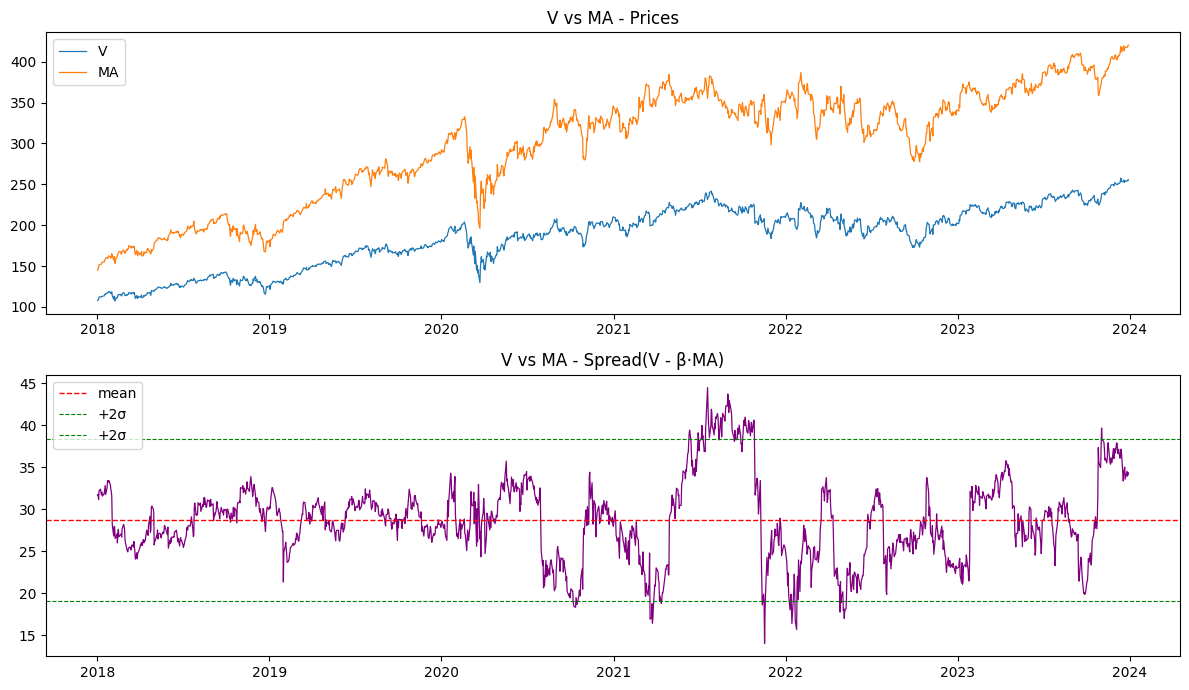

In [4]:
# plot the spread 

spread = y - beta * x

fig , axes = plt.subplots(2,1,figsize = (12,7))
# top - raw prices
axes[0].plot(prices.index , prices["V"] , label = "V", linewidth = 0.9)
axes[0].plot(prices.index , prices["MA"] , label = "MA" , linewidth = 0.9)
axes[0].set_title("V vs MA - Prices")
axes[0].legend()

# bottom - spread
axes[1].plot(prices.index , spread , color = "purple" , linewidth = 0.9)
axes[1].axhline(spread.mean() , color = "red" , linestyle = "--" , linewidth = 1, label = "mean")
axes[1].axhline(spread.mean() + 2*spread.std() ,color = "green" , linestyle = "--" ,linewidth = 0.8 , label = "+2σ")
axes[1].axhline(spread.mean() - 2*spread.std() , color = "green" , linestyle = "--" ,linewidth = 0.8 , label = "+2σ")
axes[1].set_title("V vs MA - Spread(V - β·MA)")
axes[1].legend()

plt.tight_layout()
plt.savefig("../data/spread_V_MA.png",dpi = 120)
plt.show()

In [5]:

# cointegration test on all 22 pairs
pairs_df = pd.read_csv("../data/correlated_pairs.csv")

coint_results = []
for _,row in pairs_df.iterrows():
    t1 = row["ticker_1"]
    t2 = row["ticker_2"]

    score, p_value, _ = coint(prices[t1],prices[t2])
    
    coint_results.append({
        "ticker_1" : t1,
        "ticker_2" : t2,
        "correlation" : row["correlation"],
        "coint_pvalue" : round(p_value ,6),
        "cointegrated" : p_value < 0.05 
    })

coint_df = pd.DataFrame(coint_results)
coint_df = coint_df.sort_values("coint_pvalue").reset_index(drop = True)
print(coint_df)
print(f"\nCointegrated pairs: {coint_df['cointegrated'].sum()} out  of {len(coint_df)}")

   ticker_1 ticker_2  correlation  coint_pvalue  cointegrated
0        MA        V       0.9127      0.000476          True
1        GS       MS       0.8712      0.024334          True
2         C       MS       0.8244      0.116534         False
3       CVX      XOM       0.8474      0.125961         False
4         C       GS       0.8224      0.140315         False
5       COP      XOM       0.8340      0.148607         False
6       COP      CVX       0.8422      0.175433         False
7         C      JPM       0.8681      0.195511         False
8       EOG      HAL       0.8060      0.207765         False
9       BAC       MS       0.8436      0.354213         False
10      COP      EOG       0.8665      0.369902         False
11        C      WFC       0.8146      0.376980         False
12      HAL      SLB       0.8782      0.411045         False
13      COP      SLB       0.8109      0.536043         False
14      BAC       GS       0.8345      0.571150         False
15      

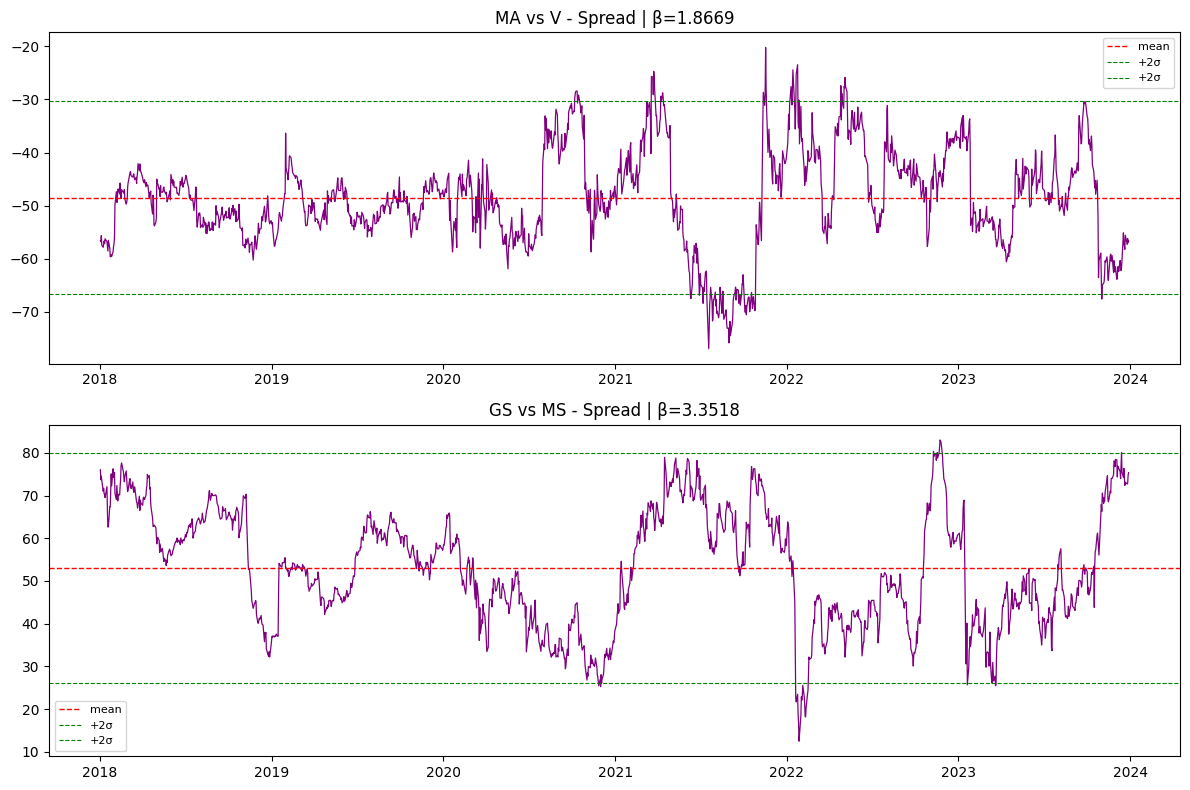

In [6]:
pairs_to_plot = [("MA","V"),("GS","MS")]

fig, axes = plt.subplots(2,1,figsize = (12,8))

for i, (t1,t2) in enumerate(pairs_to_plot):
    y = prices[t1]
    x = prices[t2]

    x_const = add_constant(x)
    model = OLS(y,x_const).fit()
    beta = model.params[t2]
    spread = y - beta * x

    axes[i].plot(prices.index , spread, linewidth = 0.9 , color = "purple")
    axes[i].axhline(spread.mean() , color = "red" , linestyle = "--" , linewidth = 1 , label = "mean")
    axes[i].axhline(spread.mean() + 2*spread.std() ,color = "green" , linestyle = "--" ,linewidth = 0.8 , label = "+2σ")
    axes[i].axhline(spread.mean() - 2*spread.std() , color = "green" , linestyle = "--" ,linewidth = 0.8 , label = "+2σ")
    axes[i].set_title(f"{t1} vs {t2} - Spread | β={beta:.4f}")
    axes[i].legend(fontsize = 8)

plt.tight_layout()
plt.savefig("../data/cointegrated_spreads.png" , dpi = 120)
plt.show()

In [7]:
coint_df.to_csv("../data/cointegrated_pairs.csv" ,index =False)
verify = pd.read_csv("../data/cointegrated_pairs.csv")
print(verify)

   ticker_1 ticker_2  correlation  coint_pvalue  cointegrated
0        MA        V       0.9127      0.000476          True
1        GS       MS       0.8712      0.024334          True
2         C       MS       0.8244      0.116534         False
3       CVX      XOM       0.8474      0.125961         False
4         C       GS       0.8224      0.140315         False
5       COP      XOM       0.8340      0.148607         False
6       COP      CVX       0.8422      0.175433         False
7         C      JPM       0.8681      0.195511         False
8       EOG      HAL       0.8060      0.207765         False
9       BAC       MS       0.8436      0.354213         False
10      COP      EOG       0.8665      0.369902         False
11        C      WFC       0.8146      0.376980         False
12      HAL      SLB       0.8782      0.411045         False
13      COP      SLB       0.8109      0.536043         False
14      BAC       GS       0.8345      0.571150         False
15      

In [8]:
from data_loader import find_cointegrated_pairs

pairs_df = pd.read_csv("../data/correlated_pairs.csv")
coint_df = find_cointegrated_pairs(prices,pairs_df)
print(f"Cointegrated pairs: {coint_df['cointegrated'].sum()}")

Cointegrated pairs: 2
